# Assignment 1
The purpose of this model is to predict iris species by sepal length and width, and petal length and width.  
The model uses a simple neural network (keras sequential). It accepts the four samples as input and outputs the predicted species.  
The model consists of an input layer, one hidden layer and an output layer.

## Data preprocessing
First, the iris dataset is loaded and examined.  
The columns *sepal_length, sepal_width, petal_length and petal_width* make up the data, while the column *species* is the target set.

In [1]:
import pandas as pd

df = pd.read_csv('datasets/iris.csv')
df.describe(include='all')

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


Next, the data and target are separated into their own variables and prepared for modeling.  
The target values are strings, which must be converted to a format that the model can use.  
This is done using one-hot-encoding, which first needs the strings to be in integer format.  

In [2]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encodes the labels to integer format, eg. 'setosa' --> 0
encoder = LabelEncoder()
X = df.drop(columns='species')
y = df['species']
y_encoded = encoder.fit_transform(y) # convert string labels to integers

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


The data also needs to be normalized in order to make the model work.    
StandardScaler scales each individual value to a number between 0-1.

In [3]:
from sklearn.preprocessing import StandardScaler

# Scale values and one-hot-encode targets
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # standardize all values
y_one_hot = to_categorical(y_encoded, num_classes=3) # setosa, versicolor, virginica

## Modeling
Now that the data is ready, the model itself will be built.
The values here were chosen after rigorous testing, getting closest to the target accuracy.

In [4]:
import keras
from keras import regularizers
# Hidden layer size of 6-16 has been tested, and the value 8 was found to produce the best results.
model = Sequential([
    Input(shape=(4,)),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')  # 3 classes
])

# Optimize learning to prevent overfitting
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Epoch numbers of 20, 40, 50, 60, 100, 150 did not produce great results, and thus 200 is the chosen value.
# Batch size 4-16 has been tested, with 4 and 8 producing better results and 4 ultimately being chosen.
history = model.fit(X_scaled, y_one_hot, epochs=200, batch_size=4, validation_split=0.2, shuffle=True, callbacks=[early_stop])

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8333 - loss: 0.8149 - val_accuracy: 0.0000e+00 - val_loss: 1.9343
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8333 - loss: 0.7546 - val_accuracy: 0.0000e+00 - val_loss: 1.7931
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8333 - loss: 0.7018 - val_accuracy: 0.0000e+00 - val_loss: 1.7283
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8333 - loss: 0.6551 - val_accuracy: 0.0000e+00 - val_loss: 1.6233
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8333 - loss: 0.6148 - val_accuracy: 0.0000e+00 - val_loss: 1.5136
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.5793 - val_accuracy: 0.0000e+00 - val_loss: 1.4597
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.5472 - val_accuracy: 0.0333 - val_loss: 1.3645
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.5187 - 

Unfortunately, the accuracy value does not seem very consistent, and does not get over 0.9333.  
The most consistent result that has been reproduced is 0.9000, which seems to be some sort of "equilibrium".  

Visualizing the learning curve might prove some insight into what is going on.

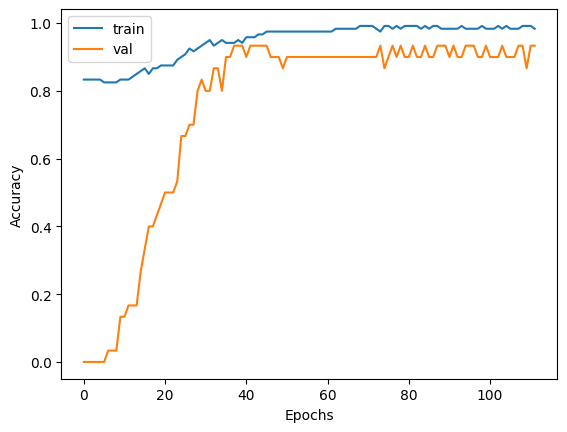

In [5]:
import matplotlib.pyplot as plt

# Draw learning curve comparing raw accuracy with validation accuracy.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

Ideally, both accuracy and validation accuracy would stabilize very near each other, but this model seems to struggle with it.  
Getting validation accuracy to 0.9000 (90%) is very achievable, but gains above it are incremental and can easily lead to overfitting.  

For a final test, 10 models will be run and their results averaged out to find how consistent these results are.

In [6]:
# try running multiple times and finding the best one
val_accuracies = []

for i in range(10):
    model = Sequential([
    Input(shape=(4,)),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(3, activation='softmax')  # 3 classes
    ])
    
    # Optimize learning to prevent overfitting
    opt = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    
    # Epoch numbers of 20, 40, 50, 60, 100, 150 did not produce great results, and thus 200 is the chosen value.
    # Batch size 4-16 has been tested, with 4 and 8 producing better results and 4 ultimately being chosen.
    history = model.fit(X_scaled, y_one_hot, epochs=200, batch_size=4, validation_split=0.2, shuffle=True, callbacks=[early_stop], verbose=0)
    val_accuracies.append(max(history.history['val_accuracy']))

print("Best val_accuracy:", max(val_accuracies))
print("Mean val_accuracy:", np.mean(val_accuracies))

Best val_accuracy: 0.9666666388511658
Mean val_accuracy: 0.9233333230018616


The mean value of validation accuracy in 10 runs hovers around 0.92, which is short of the more ideal 0.95.  
However, with 10 runs the best accuracy is by chance over the target, at 0.966. This shows potential in the model.
The iris dataset is quite small, and so trying to further optimize the model might lead to severe overfitting.  
To conclude, the model consistly approaches the goal of 0.95, but only rarely reaches or exceeds it.